In [ ]:
#A часть https://www.kaggle.com/datasets/shivamb/netflix-shows данные
import pandas as pd

data = pd.read_csv("netflix_titles.csv")
df_data = pd.DataFrame(data)

#Быстрый обзор данных (Pandas)
df_data.head()
df_data.tail() #последнии строки датасета
print(df_data.shape) #возвращает кортеж где первое число количество строк а второе столбцов
df_data.info()
df_data.describe()
df_data.describe(include="object")
print(df_data.isnull().sum())

# Заполняем режисеров и каст константой так как мы текстовые значения не можем заполнить mode и mean
df_data["director"] = df_data["director"].fillna("Unknown")
df_data["cast"] = df_data["cast"].fillna("Unknown")
df_data["country"] = df_data["country"].fillna("Unknown")
# Так как у нас в рейтинге мало значений заполним модой
mode_rating = df_data["rating"].mode()[0]
df_data["rating"] = df_data["rating"].fillna(mode_rating)
#строки где не указана дата добавления удалим так как дата чертовски важна для анализа
df_data = df_data.dropna(subset="date_added")



(8807, 12)
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


C:\Users\TOFFE\AppData\Local\Temp\ipykernel_15728\2797659499.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_data.describe(include="object")


In [7]:
#C часть 
import numpy as np

col = df_data["release_year"]
stats = {
    "Min" : col.min(),
    "Max" : col.max(),
    "Mean" : col.mean(),
    "Mediana" : col.median(),
    "Mode" : col.mode()[0]
}

quantiles_list = [0.05, 0.25, 0.5, 0.75, 0.95]
result = df_data["release_year"].quantile(quantiles_list)
print(f"{stats}\n Квантили 5, 25, 50, 75, 95:\n {result}")

variance = col.var() #показывает на сколько разьросаны данные
skewness = col.skew() #это значит что нетфликс выпустил больше новых фильмов
kurtosis = col.kurt()

print(f"Дисперсия: {variance}, Асиметрия: {skewness}, Эксцесс: {kurtosis}") #говорит о перекосе в новом контенте



{'Min': np.int64(1925), 'Max': np.int64(2021), 'Mean': np.float64(2014.1834716380583), 'Mediana': np.float64(2017.0), 'Mode': np.int64(2018)}
 Квантили 5, 25, 50, 75, 95:
 0.05    1997.0
0.25    2013.0
0.50    2017.0
0.75    2019.0
0.95    2021.0
Name: release_year, dtype: float64
Дисперсия: 77.83104556345768, Асиметрия: -3.447715993310005, Эксцесс: 16.233483212486586


In [25]:
#D
#Извлечем месяц добавления может помочь для определения сезона
df_data["date_added"] = df_data["date_added"].str.strip()
df_data["month_added"] = pd.to_datetime(df_data["date_added"]).dt.month
#Считаем количество жанров 
df_data['genre_count'] = df_data['listed_in'].apply(lambda x: len(x.split(',')))
#считаем Топ стран по выпуску и групперуем редких стран в "Other"
top_countrys = df_data["country"].value_counts().nlargest(10).index
df_data['country_grouped'] = df_data["country"].apply(lambda x: x if x in top_countrys else "Other")
#Преобразуем признак type
df_encoded = pd.get_dummies(df_data, columns=['type'], prefix='is')
#FeatureHasher
from sklearn.feature_extraction import FeatureHasher

hasher = FeatureHasher(n_features=5, input_type='string')
hashed_data = hasher.transform(df_data['country_grouped'].apply(lambda x: [x])).toarray()
hashed_df = pd.DataFrame(hashed_data, columns=[f'country_hash_{i}' for i in range(5)])
df_final = pd.concat([df_encoded.reset_index(drop=True), hashed_df], axis=1)
df_final.head()

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,...,month_added,genre_count,country_grouped,is_Movie,is_TV Show,country_hash_0,country_hash_1,country_hash_2,country_hash_3,country_hash_4
0,s1,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,...,9,1,United States,True,False,0.0,0.0,0.0,0.0,1.0
1,s2,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",...,9,3,Other,False,True,0.0,0.0,1.0,0.0,0.0
2,s3,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",...,9,3,Unknown,False,True,-1.0,0.0,0.0,0.0,0.0
3,s4,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV",...,9,2,Unknown,False,True,-1.0,0.0,0.0,0.0,0.0
4,s5,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",...,9,3,India,False,True,0.0,0.0,-1.0,0.0,0.0


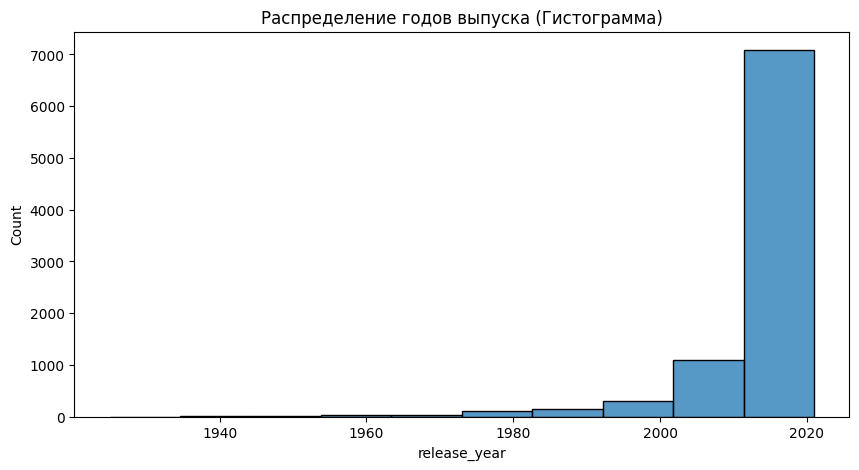

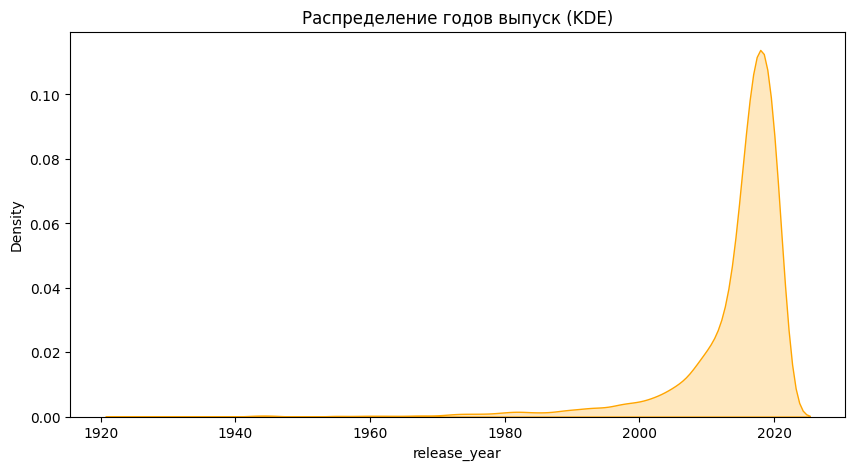

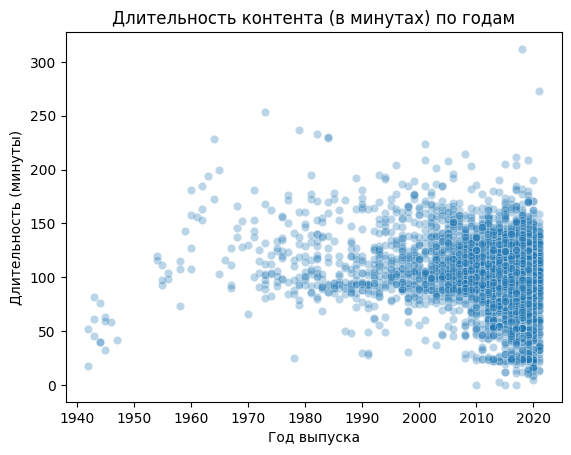

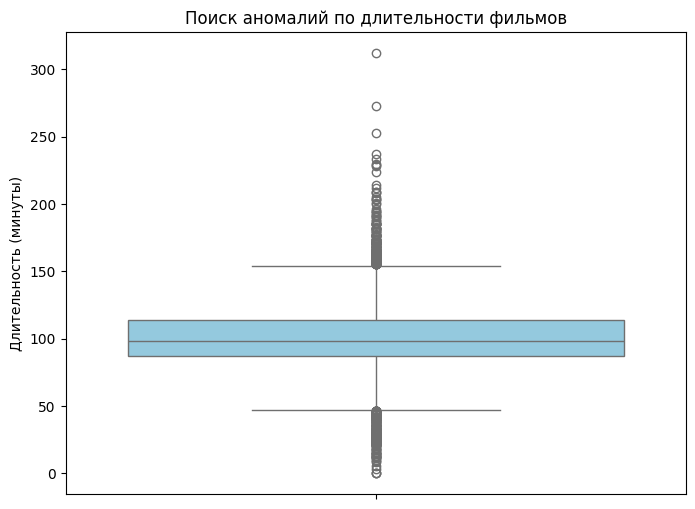

                            title  duration_minutes
166   Once Upon a Time in America               229
717   Headspace: Unwind Your Mind               273
1019                       Lagaan               224
2484           Lock Your Girls In               233
2487               No Longer kids               237
2488              Raya and Sakina               230
2491       The School of Mischief               253
4253   Black Mirror: Bandersnatch               312
7932                       Sangam               228


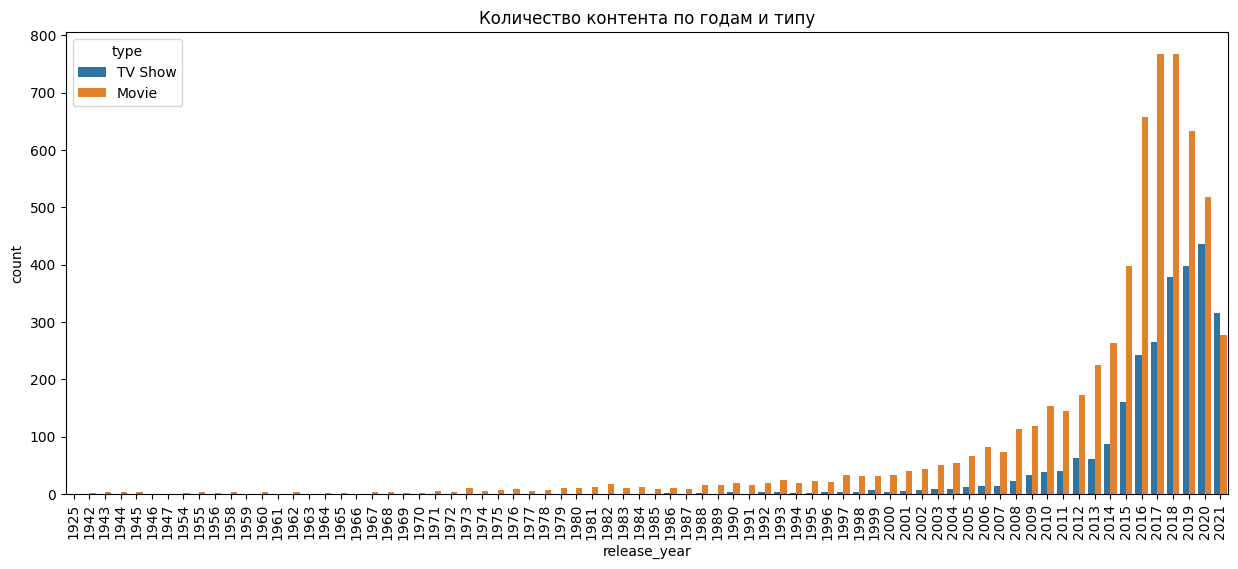

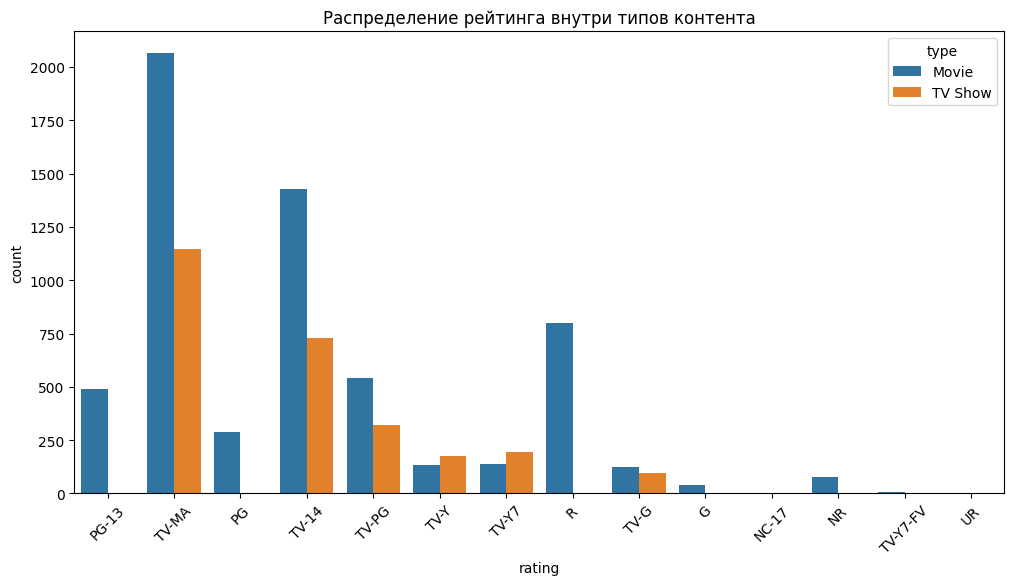

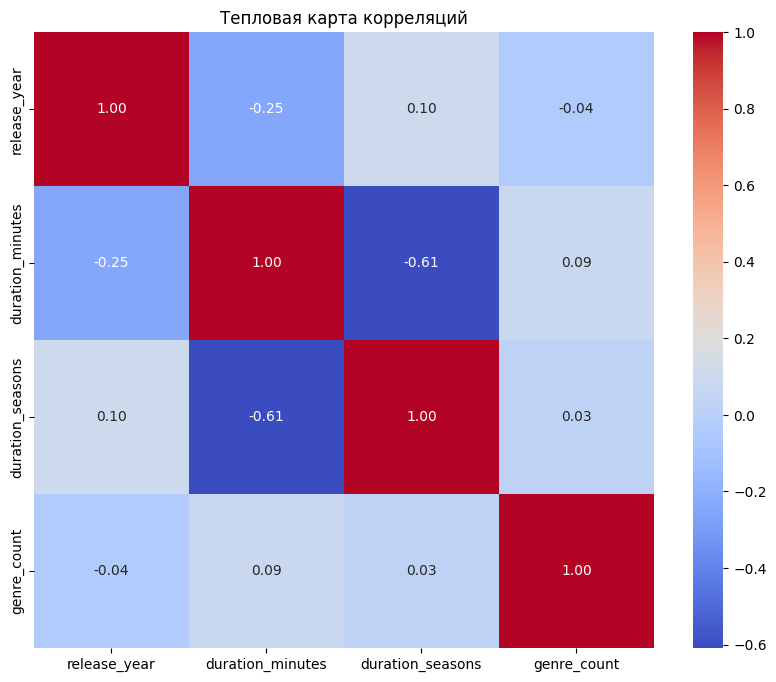

In [ ]:
#E Визуализация
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#Распределения: гистограммы 
plt.figure(figsize=(10, 5))
sns.histplot(df_data['release_year'], bins=10, kde=False)
plt.title("Распределение годов выпуска (Гистограмма)")
plt.show()
#KDE
plt.figure(figsize=(10, 5))
sns.kdeplot(df_data['release_year'], fill=True, color='orange')
plt.title("Распределение годов выпуск (KDE)")
plt.show()
#Scatter plot — ищем зависимости между числами.
def parse_duration(row):
    dur = str(row['duration'])
    if 'min' in dur:
        return int(dur.split(' ')[0]), 0
    elif 'Season' in dur:
        return 0, int(dur.split(' ')[0])
    else:
        return 0, 0
df_data[['duration_minutes', 'duration_seasons']] = df_data.apply(lambda x: pd.Series(parse_duration(x)), axis=1)
df_movies = df_data[df_data['type'] == 'Movie']
sns.scatterplot(data=df_movies, x='release_year', y='duration_minutes', alpha=0.3)
plt.title("Длительность контента (в минутах) по годам")
plt.xlabel("Год выпуска")
plt.ylabel("Длительность (минуты)")
plt.show()

#Box plot (ящик с усами) — ищем аномалии/выбросы.
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_movies['duration_minutes'], color='skyblue')
plt.title("Поиск аномалий по длительности фильмов")
plt.ylabel("Длительность (минуты)")
plt.show()
# Находим фильмы, которые длятся более 200 минут 
outliers = df_movies[df_movies['duration_minutes'] > 220]
print(outliers[['title', 'duration_minutes']])

# Bar/count plot для категорий.
plt.figure(figsize=(15, 6))
sns.countplot(data=df_data,x='release_year', hue='type', )
plt.xticks(rotation=90)
plt.title("Количество контента по годам и типу")
plt.show()

df_clean = df_data[~df_data['rating'].str.contains('min', na=False)]
plt.figure(figsize=(12, 6))
sns.countplot(data=df_clean, x='rating', hue='type')
plt.title("Распределение рейтинга внутри типов контента")
plt.xticks(rotation=45)
plt.show()

#Heatmap корреляций
numeric_cols = ['release_year', 'duration_minutes', 'duration_seasons', 'genre_count']
# Строим матрицу корреляции
correlation_matrix = df_data[numeric_cols].corr()

# Визуализируем
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Тепловая карта корреляций")
plt.show()
#видим отрицательную связь мужду датой релиза и длительность что говорит о уменьшении Хронометража
#видим положительную связь мужду датой релиза и количеством сезонов говорит о небольшой тендеции у увелечению сезонов

"""
Датасет сильно несбалансирован: фильмов в базе значительно больше, чем сериалов.
C 2015-2021 заметен значительный рост прозводства TV Show, так же в эти годы замечен бум производства TV Show и Movie
Так же в датасете замечен значительный пропуск значений в director 
Датасет сильно несбалансирован фильмов в базе значительно больше, чем сериалов.
Выбросы по длительности (очень длинные/короткие фильмы)
Большая часть TV Show и Movie с возростным рейтингом TV-MA



Рейтинг контента является сильным предиктором для определения типа (Movie или TV Show), 
так как сериалы чаще имеют специфические рейтинги типа TV-Y или TV-Y7
Контент с рейтингом TV-MA чаще имеет большее количество жанровых меток

Построил бы классификатор, чтобы предсказывать тип контента(Movie TV Show) 
на основе его длительности, года, жанра, рейтинга.

AI подсказал методику фильтрации Категориальных данных
"""